В данном листинге представленно решение пунктов f, g и h задачи Т5.

Доверительные интервалы (95%):
Точный:           [7.9931, 8.1394]
Асимптотический:  [7.7046, 8.3086]
Бутстрап (непараметрический): [7.9717, 8.0318]

Истинное θ = 8


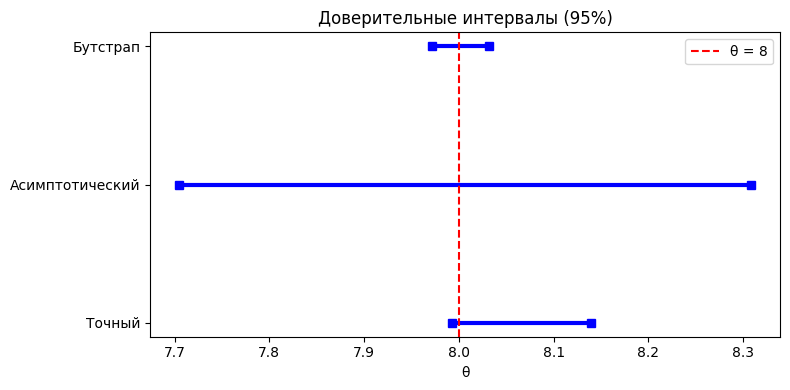

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

theta_true, n, alpha = 8, 100, 0.05
z = stats.norm.ppf(1 - alpha/2)

X = np.random.uniform(theta_true, 2*theta_true, n)
X_max, X_mean = np.max(X), np.mean(X)

theta_MM = (2/3) * X_mean
theta_ML_corr = (n+1)/(2*n+1) * X_max

left_exact = X_max / (1 + (1 - alpha/2)**(1/n))
right_exact = X_max / (1 + (alpha/2)**(1/n))

se_asymp = np.sqrt(theta_MM**2 / (27 * n))
left_asymp = theta_MM - z * se_asymp
right_asymp = theta_MM + z * se_asymp

B = 1000
boot = []
for _ in range(B):
    boot_sample = np.random.choice(X, n, replace=True)
    boot.append((n+1)/(2*n+1) * np.max(boot_sample))

left_boot, right_boot = np.percentile(boot, [100*alpha/2, 100*(1-alpha/2)])

print("Доверительные интервалы (95%):")
print(f"Точный:           [{left_exact:.4f}, {right_exact:.4f}]")
print(f"Асимптотический:  [{left_asymp:.4f}, {right_asymp:.4f}]")
print(f"Бутстрап (непараметрический): [{left_boot:.4f}, {right_boot:.4f}]")
print(f"\nИстинное θ = {theta_true}")

plt.figure(figsize=(8, 4))
methods = ["Точный", "Асимптотический", "Бутстрап"]
intervals = [(left_exact, right_exact), (left_asymp, right_asymp), (left_boot, right_boot)]
for i, (low, high) in enumerate(intervals):
    plt.hlines(i, low, high, colors='blue', linewidth=3)
    plt.plot(low, i, 's', color='blue')
    plt.plot(high, i, 's', color='blue')
plt.axvline(theta_true, color='red', linestyle='--', label=f'θ = {theta_true}')
plt.yticks(range(3), methods)
plt.xlabel('θ')
plt.title('Доверительные интервалы (95%)')
plt.legend()
plt.tight_layout()
plt.show()